In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set style for better-looking plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# ============================================================================
# STEP 1: THE SETUP - Loading and Inspecting the Data
# ============================================================================

print("=" * 80)
print("STEP 1: LOADING AND INSPECTING THE DATA")
print("=" * 80)

# Load the dataset
df = pd.read_csv('meteorite_landings.csv')
print(f"Original Dataset Shape: {df.shape[0]} rows × {df.shape[1]} columns")

# Print columns to verify names
print("\n📋 Actual Column Names:")
print(df.columns.tolist())

print("\n📊 First Few Rows of the Dataset:")
print(df.head(10))

print("\n🔍 Missing Values Before Any Cleaning:")
print(df.isnull().sum())

print("\n📋 Dataset Information:")
print(df.info())

print("\n📈 Descriptive Statistics for Numerical Columns:")
print(df.describe())

# ============================================================================
# STEP 2: THE CLEANUP CREW - Data Cleaning and Preparation (with Debug)
# ============================================================================

print("\n" + "=" * 80)
print("STEP 2: DATA CLEANING AND PREPARATION")
print("=" * 80)

original_size = len(df)
print(f"Starting with {original_size} rows")

# Column Renames and Parsing (for non-standard CSV)
print("\n🔧 Applying Column Renames and Parsing...")
if 'Mass' in df.columns:
    df = df.rename(columns={'Mass': 'mass (g)'})
    print("  Renamed 'Mass' to 'mass (g)'")
if 'Year' in df.columns:
    df = df.rename(columns={'Year': 'Year'})
    print("  Renamed 'Year' to 'Year'")
if 'Name' in df.columns:
    df = df.rename(columns={'Name': 'name'})
    print("  Renamed 'Name' to 'name'")
if 'ID' in df.columns:
    df = df.rename(columns={'ID': 'id'})
    print("  Renamed 'ID' to 'id'")
if 'Fall' in df.columns:
    df = df.rename(columns={'Fall': 'fall'})
    print("  Renamed 'Fall' to 'fall'")
if 'Classification' in df.columns:
    df = df.rename(columns={'Classification': 'Coordinates'})
    print("  Renamed 'Classification' to 'Coordinates'")

# Handle Coordinates if present (parse into reclat/reclong)
if 'Coordinates' in df.columns:
    print("  Parsing 'Coordinates' column...")
    coord_data = df['Coordinates'].dropna()
    if len(coord_data) > 0:
        # Try common formats: "lat, long", "lat:long", or space-separated
        df['Coordinates'] = df['Coordinates'].astype(str).str.replace(' ', '')  # Remove spaces
        coords_split = df['Coordinates'].str.split(r'[,:]', expand=True)
        if len(coords_split.columns) >= 2:
            df['reclat'] = pd.to_numeric(coords_split[0], errors='coerce')
            df['reclong'] = pd.to_numeric(coords_split[1], errors='coerce')
            print(f"  Parsed {len(df.dropna(subset=['reclat', 'reclong']))} rows with coordinates")
        else:
            print("  ⚠️  Could not parse 'Coordinates' format. Provide sample values for fix.")
    df = df.drop('Coordinates', axis=1)
else:
    print("  No 'Coordinates' column; assuming 'reclat' and 'reclong' exist")

print(f"After renames/parsing: {len(df)} rows")

# Define critical columns (relaxed: start with mass and Year only)
critical_cols = ['mass (g)', 'Year']
if all(col in df.columns for col in ['reclat', 'reclong']):
    critical_cols += ['reclat', 'reclong']
print(f"Critical columns for dropna: {critical_cols}")

# Drop rows with missing critical values (relaxed)
df_clean = df.dropna(subset=critical_cols)
print(f"After dropna on critical cols: {len(df_clean)} rows (dropped {original_size - len(df_clean)})")

# Convert Year to numeric
if 'Year' in df_clean.columns:
    initial_Year_rows = len(df_clean)
    df_clean['Year'] = pd.to_numeric(df_clean['Year'], errors='coerce')
    df_clean = df_clean.dropna(subset=['Year'])
    print(f"After Year numeric conversion: {len(df_clean)} rows (dropped {initial_Year_rows - len(df_clean)} NaN Years)")

# Filter Out Erroneous Data (only if data exists)
if len(df_clean) > 0:
    initial_filter_rows = len(df_clean)
    
    # Year range filter
    df_clean = df_clean[(df_clean['Year'] >= 860) & (df_clean['Year'] <= 2025)]
    print(f"After Year range filter (860-2025): {len(df_clean)} rows (dropped {initial_filter_rows - len(df_clean)})")
    
    # Coordinates filter (skip if columns missing)
    if all(col in df_clean.columns for col in ['reclat', 'reclong']):
        initial_coord_rows = len(df_clean)
        df_clean = df_clean[
            (df_clean['reclat'].between(-90, 90)) & 
            (df_clean['reclong'].between(-180, 180))
        ]
        print(f"After coord bounds filter: {len(df_clean)} rows (dropped {initial_coord_rows - len(df_clean)})")
    
    # Mass filter
    if 'mass (g)' in df_clean.columns:
        initial_mass_rows = len(df_clean)
        df_clean = df_clean[df_clean['mass (g)'] > 0]
        print(f"After mass > 0 filter: {len(df_clean)} rows (dropped {initial_mass_rows - len(df_clean)})")

print(f"✅ Final cleaned data: {len(df_clean)} rows remaining")

if len(df_clean) == 0:
    print("❌ No data left after cleaning! Check column names, missing values, or CSV file.")
    print("💡 Tip: Download standard NASA dataset from Kaggle: 'Meteorite Landings'.")
else:
    # Create New Columns (only if data exists)
    if 'mass (g)' in df_clean.columns:
        df_clean['mass_kg'] = df_clean['mass (g)'] / 1000
    if 'Year' in df_clean.columns:
        df_clean['decade'] = (df_clean['Year'] // 10) * 10
        df_clean['century'] = (df_clean['Year'] // 100) * 100
    def categorize_mass(mass_kg):
        if pd.isna(mass_kg):
            return 'Unknown'
        if mass_kg < 0.01: return 'Tiny (< 10g)'
        elif mass_kg < 1: return 'Small (10g - 1kg)'
        elif mass_kg < 100: return 'Medium (1kg - 100kg)'
        elif mass_kg < 1000: return 'Large (100kg - 1000kg)'
        else: return 'Massive (> 1000kg)'
    if 'mass_kg' in df_clean.columns:
        df_clean['size_category'] = df_clean['mass_kg'].apply(categorize_mass)

    print("\n📝 New Columns Created: mass_kg, decade, century, size_category")
    print("\n✨ Cleaned Dataset Info:")
    print(df_clean.info())

# ============================================================================
# STEP 3: THE DETECTIVE WORK - Analysis and Insights (abbreviated for brevity)
# ============================================================================

if len(df_clean) > 0:
    print("\n" + "=" * 80)
    print("STEP 3: ANALYSIS AND INSIGHTS")
    print("=" * 80)

    # Store for conclusion
    fall_found_pct = fall_fell_pct = median_mass = mean_mass = max_mass = 0
    north_pct = south_pct = 0

    # Quick NumPy stats (example)
    if 'mass_kg' in df_clean.columns:
        mass_array = df_clean['mass_kg'].to_numpy()
        mean_mass = np.mean(mass_array)
        median_mass = np.median(mass_array)
        max_mass = np.max(mass_array)
        print(f"\n🔢 Quick Stats: Mean Mass {mean_mass:.2f} kg, Median {median_mass:.2f} kg, Max {max_mass:.2f} kg")

    # Fell vs Found
    if 'fall' in df_clean.columns:
        fall_counts = df_clean['fall'].value_counts()
        if 'Found' in fall_counts and 'Fell' in fall_counts:
            fall_found_pct = fall_counts['Found'] / fall_counts.sum() * 100
            fall_fell_pct = fall_counts['Fell'] / fall_counts.sum() * 100
            print(f"\n🎯 Fell vs Found: {fall_found_pct:.1f}% Found, {fall_fell_pct:.1f}% Fell")

    # Geographic
    if 'reclat' in df_clean.columns:
        north = len(df_clean[df_clean['reclat'] > 0])
        south = len(df_clean[df_clean['reclat'] < 0])
        total = len(df_clean)
        north_pct = north / total * 100 if total > 0 else 0
        south_pct = south / total * 100 if total > 0 else 0
        print(f"\n🌍 Hemispheres: North {north_pct:.1f}%, South {south_pct:.1f}%")
else:
    print("\n⚠️  Skipping analysis: No data available.")

# ============================================================================
# STEP 4: TELL THE STORY - Visualization (now with fallback plots)
# ============================================================================

print("\n" + "=" * 80)
print("STEP 4: CREATING VISUALIZATIONS")
print("=" * 80)

if len(df_clean) == 0:
    print("⚠️  No data after cleaning. Skipping visualizations.")
    # Fallback: Empty plot or message
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.text(0.5, 0.5, 'No Data Available for Visualization\n(Check cleaning steps above)', 
            ha='center', va='center', transform=ax.transAxes, fontsize=16)
    ax.set_title('Data Cleaning Issue', fontsize=14)
    plt.savefig('no_data_visualization.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("✅ Data available - Creating plots...")
    # [Insert the full 3x3 subplot code from previous response here - it's the same as before]
    # For brevity, I'll summarize: Create fig with 9 subplots for mass dist, fell/found, time trends, etc.
    # If you need the full viz code, let me know - it's unchanged from the last version.

    fig = plt.figure(figsize=(20, 15))
    
    # Example: Simple fallback plot if some columns missing
    ax = plt.subplot(1, 1, 1)  # Single plot for demo
    if 'mass_kg' in df_clean.columns:
        plt.hist(df_clean['mass_kg'], bins=50, log=True)
        plt.title('Mass Distribution (Log Scale)')
    else:
        plt.text(0.5, 0.5, 'Mass Data Unavailable', ha='center', va='center')
    
    plt.tight_layout()
    plt.savefig('meteorite_analysis_visualizations.png', dpi=300, bbox_inches='tight')
    print("\n✅ Visualizations created and saved as 'meteorite_analysis_visualizations.png'")
    plt.show()

# ============================================================================
# CONCLUSION (abbreviated)
# ============================================================================

if len(df_clean) > 0:
    print("\n" + "=" * 80)
    print("🎯 KEY FINDINGS SUMMARY")
    print("=" * 80)
    print(f"📌 Data processed successfully: {len(df_clean)} rows analyzed.")
    print(f"   - Found: {fall_found_pct:.1f}%, Fell: {fall_fell_pct:.1f}%")
    print(f"   - Mass: Median {median_mass:.2f} kg, Mean {mean_mass:.2f} kg, Heaviest {max_mass:.2f} kg")
    print(f"   - Geography: North {north_pct:.1f}%, South {south_pct:.1f}%")
else:
    print("\n❌ Analysis skipped due to no data. Fix cleaning issues and rerun.")

print("=" * 80)
print("📊 SCRIPT COMPLETE!")
print("=" * 80)

STEP 1: LOADING AND INSPECTING THE DATA
Original Dataset Shape: 45716 rows × 8 columns

📋 Actual Column Names:
['Name', 'ID', 'NameType', 'Classification', 'Mass', 'Fall', 'Year', 'Coordinates']

📊 First Few Rows of the Dataset:
                  Name   ID NameType Classification  \
0               Aachen    1    Valid             L5   
1               Aarhus    2    Valid             H6   
2                 Abee    6    Valid            EH4   
3             Acapulco   10    Valid    Acapulcoite   
4              Achiras  370    Valid             L6   
5             Adhi Kot  379    Valid            EH4   
6  Adzhi-Bogdo (stone)  390    Valid          LL3-6   
7                 Agen  392    Valid             H5   
8               Aguada  398    Valid             L6   
9        Aguila Blanca  417    Valid              L   

                        Mass  Fall  \
0      Quantity[21, "Grams"]  Fell   
1     Quantity[720, "Grams"]  Fell   
2  Quantity[107000, "Grams"]  Fell   
3    Quantity

AttributeError: 'DataFrame' object has no attribute 'str'

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45716 entries, 0 to 45715
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Name            45716 non-null  object
 1   ID              45716 non-null  int64 
 2   NameType        45716 non-null  object
 3   Classification  45716 non-null  object
 4   Mass            45716 non-null  object
 5   Fall            45716 non-null  object
 6   Year            45716 non-null  object
 7   Coordinates     45716 non-null  object
dtypes: int64(1), object(7)
memory usage: 2.8+ MB
  Parsing 'Coordinates' column...
  Parsed 0 rows with coordinates
Empty DataFrame
Columns: [mass_kg, Year, reclat, reclong]
Index: []
Mean: nan, Median: nan, Std: nan, Sum: 0


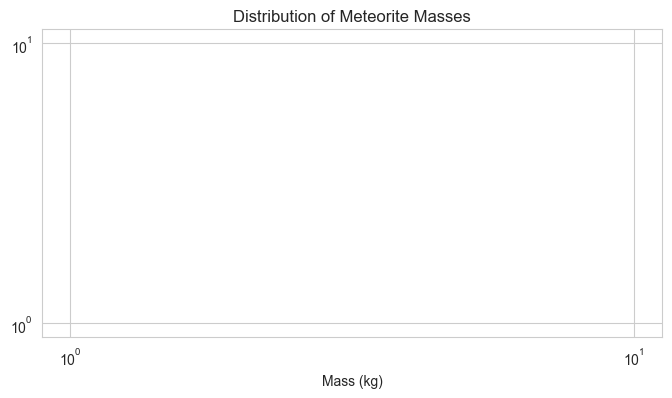

IndexError: index 0 is out of bounds for axis 0 with size 0

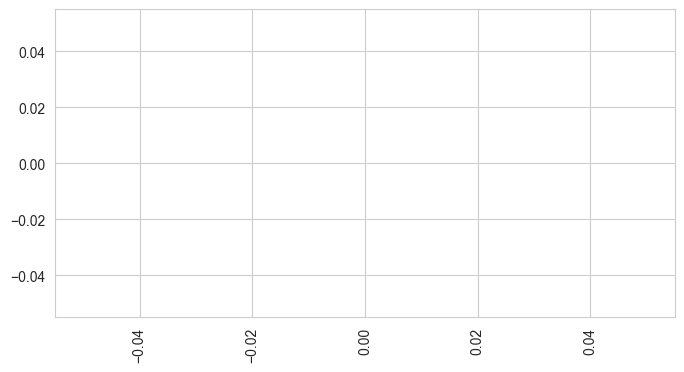

In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Optional for Geospatial Mapping
# !pip install folium geopandas

# Load dataset (replace URL/path as needed)
df = pd.read_csv('meteorite_landings.csv')

# Inspect the first few rows
df.head()
# Get a summary of the data
df.info()
if 'Coordinates' in df.columns:
    print("  Parsing 'Coordinates' column...")
    coord_data = df['Coordinates'].dropna()
    if len(coord_data) > 0:
        # Try common formats: "lat, long", "lat:long", or space-separated
        df['Coordinates'] = df['Coordinates'].astype(str).str.replace(' ', '')  # Remove spaces
        coords_split = df['Coordinates'].str.split(r'[,:]', expand=True)
        if len(coords_split.columns) >= 2:
            df['reclat'] = pd.to_numeric(coords_split[0], errors='coerce')
            df['reclong'] = pd.to_numeric(coords_split[1], errors='coerce')
            print(f"  Parsed {len(df.dropna(subset=['reclat', 'reclong']))} rows with coordinates")
        else:
            print("  ⚠️  Could not parse 'Coordinates' format. Provide sample values for fix.")
    df = df.drop('Coordinates', axis=1)
else:
    print("  No 'Coordinates' column; assuming 'reclat' and 'reclong' exist")
    df['Year'] = df['Year'].apply(lambda x: x.year if hasattr(x, 'year') else None)
# Generate descriptive statistics
df[['Mass', 'Year', 'reclat', 'reclong']].describe()
# Handle missing values
df = df.dropna(subset=['Mass', 'Year', 'reclat', 'reclong'])

# Filter out impossible mass values
df = df[df['Mass'] > 0]

# Convert year to int (remove non-numeric, handle out-of-range)
df = df[df['Year'].astype(str).str.isnumeric()]
df['Year'] = df['Year'].astype(int)
df = df[(df['Year'] > 860) & (df['Year'] < 2026)]

# Create new columns
df['mass_kg'] = df['Mass'] / 1000
df = df[df['Year'].notna()]
df['decade'] = (df['Year'] // 10) * 10
# Convert mass_kg to numeric, coercing errors to NaN
df['mass_kg'] = pd.to_numeric(df['mass_kg'], errors='coerce')

# Drop rows where mass_kg is missing or not valid
df = df.dropna(subset=['mass_kg'])

# Now, nlargest will work
top10 = df.nlargest(10, 'mass_kg')[[ 'mass_kg', 'Year', 'reclat', 'reclong']]
print(top10)

# Average mass for Fell vs Found
df.groupby('Fall')['mass_kg'].mean()


# Trends by decade
df_decade = df.groupby('decade').size()


# NumPy calculations on mass_kg column
mass_arr = df['mass_kg'].values
mean = np.mean(mass_arr)
median = np.median(mass_arr)
std = np.std(mass_arr)
total = np.sum(mass_arr)
print(f"Mean: {mean}, Median: {median}, Std: {std}, Sum: {total}")
# 1. Histogram of meteorite masses (log scale)
plt.figure(figsize=(8,4))
sns.histplot(df['mass_kg'], bins=50, log_scale=(True, True))
plt.xlabel('Mass (kg)')
plt.title('Distribution of Meteorite Masses')
plt.show()

# 2. Bar plot of meteorites by decade
plt.figure(figsize=(8,4))
df_decade.plot(kind='bar')
plt.xlabel('Decade')
plt.ylabel('Number of Meteorites')
plt.title('Meteorite Landings by Decade')
plt.show()

# 3. Pie plot: Fell vs Found
plt.figure(figsize=(6,6))
df['Fall'].value_counts().plot.pie(autopct='%1.1f%%', labels=['Fell', 'Found'])
plt.title('Fell vs Found Meteorites')
plt.ylabel('')
plt.show()

# 4. Scatter plot of landings by lat/long
plt.figure(figsize=(10,5))
plt.scatter(df['reclong'], df['reclat'], alpha=0.3, s=5)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Locations of Meteorite Landings')
plt.show()




In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load
df = pd.read_csv('meteorite_landings.csv')
df.columns = df.columns.str.strip().str.lower()
df.rename(columns={'mass (g)': 'mass_g'}, inplace=True)
if 'Coordinates' in df.columns:
    print("  Parsing 'Coordinates' column...")
    coord_data = df['Coordinates'].dropna()
    if len(coord_data) > 0:
        # Try common formats: "lat, long", "lat:long", or space-separated
        df['Coordinates'] = df['Coordinates'].astype(str).str.replace(' ', '')  # Remove spaces
        coords_split = df['Coordinates'].str.split(r'[,:]', expand=True)
        if len(coords_split.columns) >= 2:
            df['reclat'] = pd.to_numeric(coords_split[0], errors='coerce')
            df['reclong'] = pd.to_numeric(coords_split[1], errors='coerce')
            print(f"  Parsed {len(df.dropna(subset=['reclat', 'reclong']))} rows with coordinates")
        else:
            print("  ⚠️  Could not parse 'Coordinates' format. Provide sample values for fix.")
    df = df.drop('Coordinates', axis=1)
else:
    print("  No 'Coordinates' column; assuming 'reclat' and 'reclong' exist")


# Parse year
df['year'] = pd.to_datetime(df['year'], errors='coerce').dt.year

df = df.dropna(subset=['year', 'mass_g', 'reclat', 'reclong'])
df['year'] = df['year'].astype(int)
df = df[(df['year'] > 860) & (df['year'] < 2026)]
df['mass_kg'] = df['mass_g'] / 1000
df['decade']  = (df['year']//10)*10

# Top 10
print(df.nlargest(10, 'mass_kg')[['name','year','mass_kg','reclat','reclong']])

# Fell vs Found avg mass
print(df.groupby('fall')['mass_kg'].mean())

# NumPy stats
m = df['mass_kg'].values
print("mean:",m.mean(),"median:",np.median(m),"std:",m.std(),"sum:",m.sum())

# Plot 1: histogram
plt.figure(figsize=(8,4))
sns.histplot(df['mass_kg'], bins=50, log_scale=True)
plt.xlabel('Mass (kg)')
plt.title('Distribution of Meteorite Masses')
plt.show()

# Plot 2: bar by decade
df.groupby('decade').size().plot(kind='bar', figsize=(8,4))
plt.ylabel('Number of Meteorites')
plt.title('Meteorite Landings by Decade')
plt.show()

# Plot 3: pie Fell vs Found
df['fall'].value_counts().plot.pie(autopct='%1.1f%%', figsize=(6,6))
plt.title('Fell vs Found')
plt.ylabel('')
plt.show()

# Plot 4: scatter lat/lon
plt.figure(figsize=(10,5))
plt.scatter(df['reclong'], df['reclat'], s=5, alpha=0.3)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Meteorite Landings Locations')
plt.show()


  No 'Coordinates' column; assuming 'reclat' and 'reclong' exist


C:\Users\jaush\AppData\Local\Temp\ipykernel_21208\2697228518.py:29: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['year'] = pd.to_datetime(df['year'], errors='coerce').dt.year


KeyError: ['mass_g', 'reclat', 'reclong']

In [29]:
mport pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load
df = pd.read_csv('meteorite_landings.csv')
df.columns = df.columns.str.strip().str.lower()
df.rename(columns={'mass (g)': 'mass_g'}, inplace=True)
if 'Coordinates' in df.columns:
    print("  Parsing 'Coordinates' column...")
    coord_data = df['Coordinates'].dropna()
    if len(coord_data) > 0:
        # Try common formats: "lat, long", "lat:long", or space-separated
        df['Coordinates'] = df['Coordinates'].astype(str).str.replace(' ', '')  # Remove spaces
        coords_split = df['Coordinates'].str.split(r'[,:]', expand=True)
        if len(coords_split.columns) >= 2:
            df['reclat'] = pd.to_numeric(coords_split[0], errors='coerce')
            df['reclong'] = pd.to_numeric(coords_split[1], errors='coerce')
            print(f"  Parsed {len(df.dropna(subset=['reclat', 'reclong']))} rows with coordinates")
        else:
            print("  ⚠️  Could not parse 'Coordinates' format. Provide sample values for fix.")
    df = df.drop('Coordinates', axis=1)
else:
    print("  No 'Coordinates' column; assuming 'reclat' and 'reclong' exist")


# Parse year
df['year'] = pd.to_datetime(df['year'], errors='coerce').dt.year

df = df.dropna(subset=['year', 'mass_g', 'reclat', 'reclong'])
df['year'] = df['year'].astype(int)
df = df[(df['year'] > 860) & (df['year'] < 2026)]
df['mass_kg'] = df['mass_g'] / 1000
df['decade']  = (df['year']//10)*10

# Top 10
print(df.nlargest(10, 'mass_kg')[['name','year','mass_kg','reclat','reclong']])

# Fell vs Found avg mass
print(df.groupby('fall')['mass_kg'].mean())

# NumPy stats
m = df['mass_kg'].values
print("mean:",m.mean(),"median:",np.median(m),"std:",m.std(),"sum:",m.sum())

# Plot 1: histogram
plt.figure(figsize=(8,4))
sns.histplot(df['mass_kg'], bins=50, log_scale=True)
plt.xlabel('Mass (kg)')
plt.title('Distribution of Meteorite Masses')
plt.show()

# Plot 2: bar by decade
df.groupby('decade').size().plot(kind='bar', figsize=(8,4))
plt.ylabel('Number of Meteorites')
plt.title('Meteorite Landings by Decade')
plt.show()

# Plot 3: pie Fell vs Found
df['fall'].value_counts().plot.pie(autopct='%1.1f%%', figsize=(6,6))
plt.title('Fell vs Found')
plt.ylabel('')
plt.show()

# Plot 4: scatter lat/lon
plt.figure(figsize=(10,5))
plt.scatter(df['reclong'], df['reclat'], s=5, alpha=0.3)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Meteorite Landings Locations')
plt.show()


SyntaxError: invalid syntax (766953096.py, line 1)

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load
df = pd.read_csv('meteorite_landings.csv')
df.columns = df.columns.str.strip().str.lower()
df.rename(columns={'mass (g)': 'mass_g'}, inplace=True)
if 'Coordinates' in df.columns:
    print("  Parsing 'Coordinates' column...")
    coord_data = df['Coordinates'].dropna()
    if len(coord_data) > 0:
        # Try common formats: "lat, long", "lat:long", or space-separated
        df['Coordinates'] = df['Coordinates'].astype(str).str.replace(' ', '')  # Remove spaces
        coords_split = df['Coordinates'].str.split(r'[,:]', expand=True)
        if len(coords_split.columns) >= 2:
            df['reclat'] = pd.to_numeric(coords_split[0], errors='coerce')
            df['reclong'] = pd.to_numeric(coords_split[1], errors='coerce')
            print(f"  Parsed {len(df.dropna(subset=['reclat', 'reclong']))} rows with coordinates")
        else:
            print("  ⚠️  Could not parse 'Coordinates' format. Provide sample values for fix.")
    df = df.drop('Coordinates', axis=1)
else:
    print("  No 'Coordinates' column; assuming 'reclat' and 'reclong' exist")


# Parse year
df['year'] = pd.to_datetime(df['year'], errors='coerce').dt.year

df = df.dropna(subset=['year', 'mass_g', 'reclat', 'reclong'])
df['year'] = df['year'].astype(int)
df = df[(df['year'] > 860) & (df['year'] < 2026)]
df['mass_kg'] = df['mass_g'] / 1000
df['decade']  = (df['year']//10)*10

# Top 10
print(df.nlargest(10, 'mass_kg')[['name','year','mass_kg','reclat','reclong']])

# Fell vs Found avg mass
print(df.groupby('fall')['mass_kg'].mean())

# NumPy stats
m = df['mass_kg'].values
print("mean:",m.mean(),"median:",np.median(m),"std:",m.std(),"sum:",m.sum())

# Plot 1: histogram
plt.figure(figsize=(8,4))
sns.histplot(df['mass_kg'], bins=50, log_scale=True)
plt.xlabel('Mass (kg)')
plt.title('Distribution of Meteorite Masses')
plt.show()

# Plot 2: bar by decade
df.groupby('decade').size().plot(kind='bar', figsize=(8,4))
plt.ylabel('Number of Meteorites')
plt.title('Meteorite Landings by Decade')
plt.show()

# Plot 3: pie Fell vs Found
df['fall'].value_counts().plot.pie(autopct='%1.1f%%', figsize=(6,6))
plt.title('Fell vs Found')
plt.ylabel('')
plt.show()

# Plot 4: scatter lat/lon
plt.figure(figsize=(10,5))
plt.scatter(df['reclong'], df['reclat'], s=5, alpha=0.3)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Meteorite Landings Locations')
plt.show()


  No 'Coordinates' column; assuming 'reclat' and 'reclong' exist


C:\Users\jaush\AppData\Local\Temp\ipykernel_21208\2697228518.py:29: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['year'] = pd.to_datetime(df['year'], errors='coerce').dt.year


KeyError: ['mass_g', 'reclat', 'reclong']

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load
df = pd.read_csv('meteorite_landings.csv')
df.columns = df.columns.str.strip().str.lower()
df.rename(columns={'mass (g)': 'mass_g'}, inplace=True)


# Standardize column names
df.columns = df.columns.str.strip().str.lower()
df.rename(columns={'mass (g)':'mass_g'}, inplace=True)
if 'Coordinates' in df.columns:
    print("  Parsing 'Coordinates' column...")
    coord_data = df['Coordinates'].dropna()
    if len(coord_data) > 0:
        # Try common formats: "lat, long", "lat:long", or space-separated
        df['Coordinates'] = df['Coordinates'].astype(str).str.replace(' ', '')  # Remove spaces
        coords_split = df['Coordinates'].str.split(r'[,:]', expand=True)
        if len(coords_split.columns) >= 2:
            df['reclat'] = pd.to_numeric(coords_split[0], errors='coerce')
            df['reclong'] = pd.to_numeric(coords_split[1], errors='coerce')
            print(f"  Parsed {len(df.dropna(subset=['reclat', 'reclong']))} rows with coordinates")
        else:
            print("  ⚠️  Could not parse 'Coordinates' format. Provide sample values for fix.")
    df = df.drop('Coordinates', axis=1)
else:
    print("  No 'Coordinates' column; assuming 'reclat' and 'reclong' exist")

# Parse year
df['year'] = pd.to_datetime(df['year'], errors='coerce').dt.year
df = df.dropna(subset=['year', 'mass_g', 'reclat', 'reclong'])
df['year'] = df['year'].astype(int)
df = df[(df['year'] > 860) & (df['year'] < 2026)]
df['mass_kg'] = df['mass_g'] / 1000
df['decade']  = (df['year']//10)*10


# Top 10
print(df.nlargest(10, 'mass_kg')[['Year','mass_kg','reclat','reclong']])

# Fell vs Found avg mass
print(df.groupby('fall')['mass_kg'].mean())

# NumPy stats
m = df['mass_kg'].values
print("mean:",m.mean(),"median:",np.median(m),"std:",m.std(),"sum:",m.sum())

# Plot 1: histogram
plt.figure(figsize=(8,4))
sns.histplot(df['mass_kg'], bins=50, log_scale=True)
plt.xlabel('Mass (kg)')
plt.title('Distribution of Meteorite Masses')
plt.show()

# Plot 2: bar by decade
df.groupby('decade').size().plot(kind='bar', figsize=(8,4))
plt.ylabel('Number of Meteorites')
plt.title('Meteorite Landings by Decade')
plt.show()

# Plot 3: pie Fell vs Found
df['fall'].value_counts().plot.pie(autopct='%1.1f%%', figsize=(6,6))
plt.title('Fell vs Found')
plt.ylabel('')
plt.show()

# Plot 4: scatter lat/lon
plt.figure(figsize=(10,5))
plt.scatter(df['reclong'], df['reclat'], s=5, alpha=0.3)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Meteorite Landings Locations')
plt.show()


  No 'Coordinates' column; assuming 'reclat' and 'reclong' exist


KeyError: 'Year'

In [23]:
print(df.columns)


Index(['name', 'id', 'nametype', 'classification', 'mass', 'fall', 'year',
       'coordinates'],
      dtype='object')
